In [1]:
import os

os.listdir()

['.anaconda',
 '.android',
 '.bash_history',
 '.conda',
 '.condarc',
 '.continuum',
 '.copilot',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.lesshst',
 '.matplotlib',
 '.packettracer',
 '.viminfo',
 '.vscode',
 '.vscode-shared',
 'a.exe',
 'Abdominal infection.ipynb',
 'abdominal.zip',
 'abdominal_data',
 'abdominal_label_encoder.pkl',
 'abdominal_random_forest_model.pkl',
 'abdominal_scaler.pkl',
 'abdominal_sepsis_ready.csv',
 'anaconda3',
 'AppData',
 'Apple',
 'Application Data',
 'C Tutorials',
 'cars1.csv',
 'cars2.csv',
 'chipotle.tsv',
 'Cisco Packet Tracer 8.2.2',
 'combine_uti_datasets.ipynb',
 'concat, merge.ipynb',
 'Contacts',
 'Cookies',
 'Copy of wine.data',
 'COVID.ipynb',
 'csv_mindex.csv',
 'dataframe, missing values (1).ipynb',
 'dataframe, missing values.ipynb',
 'Documents',
 'Downloads',
 'Dropbox',
 'Early_Sepsis_Detection.ipynb',
 'ex1.csv',
 'ex1.xlsx',
 'ex2.csv',
 'ex5.csv',
 'ex6.csv',
 'Favorites',
 'final_unifi

 Unzip & Load the Dataset

In [2]:
import pandas as pd
import zipfile
import os

# Unzip the dataset
with zipfile.ZipFile("pnemonia.zip", "r") as zip_ref:
    zip_ref.extractall("Pneumonia_dataset")

# Confirm CSV exists
csv_path = "Pneumonia_dataset/Pneumonia_dataset.csv"
print("CSV exists:", os.path.exists(csv_path))

#  Load CSV
data = pd.read_csv(csv_path)

# View first rows
data.head()


CSV exists: True


,PatientID,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,Oxygen_saturation,Crackles,Xray,WBC_count,Sputum_color,Temperature,Diagnosis
0,P00001,F,63,NaN,NaN,Mild,NaN,Mild,No,97,Yes,-,-,Clear,36.7,No
1,P00002,M,65,Dry,Low,NaN,Moderate,Mild,No,87,No,-,-,Green,36.8,Yes
2,P00003,F,45,Wet,Low,NaN,Moderate,Moderate,Yes,90,Yes,-,-,Yellow,38.1,Yes
3,P00004,M,10,Dry,Low,NaN,Mild,Mild,No,96,Yes,-,-,Yellow,35.0,No
4,P00005,M,2,Dry,NaN,NaN,Mild,Mild,-,87,Yes,-,-,-,37.7,No


Inspect Columns

In [3]:
data.columns

Index(['PatientID', 'Gender', 'Age', 'Cough', 'Fever', 'Shortness_of_breath',
       'Chest_pain', 'Fatigue', 'Confusion', 'Oxygen_saturation', 'Crackles',
       'Xray', 'WBC_count', 'Sputum_color', 'Temperature', 'Diagnosis'],
      dtype='object')

In [4]:
data.shape

(1900, 16)


Drop Irrelevant Columns (CLEANING)

In [5]:
drop_cols = [
    "PatientID", "Diagnosis",  "Sputum_color", "Xray"
]
data = data.drop(columns=drop_cols, errors="ignore")


In [6]:
# STANDARDIZE COLUMN NAMES
data.rename(columns={
    "Temperature": "body_temperature",
    "Oxygen_saturation" : "oxygen_saturation" ,
    "WBC_count": "wbc_count"
}, inplace=True)

In [7]:
# HANDLE MISSING CATEGORICAL VALUES
categorical_cols = [
    "Gender", "Cough", "Fever", "Shortness_of_breath",
    "Chest_pain", "Fatigue", "Confusion",
    "Crackles"
]

for col in categorical_cols:
    data[col] = data[col].fillna("Unknown")



ENCODING

In [8]:
# Binary mappings
binary_map = {
    "Yes": 1, "No": 0,
    "Y": 1, "N": 0,
    "M": 1, "F": 0
}

for col in ["Gender", "Confusion", "Crackles"]:
    data[col] = data[col].map(binary_map)


In [9]:
# Ordinal symptom severity
severity_map = {
    "Low": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "High": 3,
    "Unknown": 1
}

for col in ["Fever", "Shortness_of_breath", "Chest_pain", "Fatigue"]:
    data[col] = data[col].map(severity_map)


In [10]:
# Cough type
data["Cough"] = data["Cough"].replace({
    "Dry": 1,
    "Bloody": 2,
    "Unknown": 0
})


numeric cleaning

In [11]:
numeric_cols = [
    "Age",
    "body_temperature",
    "oxygen_saturation",
    "wbc_count"
    
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())


In [12]:
data[numeric_cols].isnull().sum()

Age                  0
body_temperature     0
oxygen_saturation    0
wbc_count            0
dtype: int64

In [13]:
data.isnull().sum()

Gender                   0
Age                      0
Cough                    0
Fever                    0
Shortness_of_breath      0
Chest_pain               0
Fatigue                  0
Confusion              186
oxygen_saturation        0
Crackles                 0
wbc_count                0
body_temperature         0
dtype: int64

In [14]:
def safe_mode(series, default=0):
    mode_val = series.mode()
    if len(mode_val) > 0:
        return mode_val.iloc[0]
    else:
        return default

# FIX BINARY COLUMNS 

binary_cols = ["Confusion"]

for col in binary_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(safe_mode(data[col], default=0))



In [15]:
data[binary_cols].isnull().sum()

Confusion    0
dtype: int64

In some cases, after categorical mapping, a column may contain only NaN values. Therefore, we used a safe mode function with a default value to ensure robustness and prevent runtime errors.


ADD MISSING VITALS (DATA ENHANCEMENT) :

The dataset lacks certain early sepsis vital signs.For academic purposes, we approximate these vitals using clinically realistic ranges for non-ICU patients.

In [16]:
import numpy as np

np.random.seed(42)  # reproducibility

# Synthetic non-ICU vitals (clinically realistic ranges)
data["heart_rate"] = np.random.randint(60, 120, size=len(data))
data["respiratory_rate"] = np.random.randint(12, 28, size=len(data))
data["systolic_bp"] = np.random.randint(95, 140, size=len(data))
data["platelets"] = np.random.randint(100000, 300000, size=len(data))


In [17]:
final_numeric_cols = [
    "Age",
    "Gender",
    "Cough",
    "Fever",
    "Shortness_of_breath",
    "Chest_pain",
    "Fatigue",
    "Confusion",
    "oxygen_saturation",
    "Crackles",
    "wbc_count",
    "body_temperature",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "platelets"
]

for col in final_numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())


CREATE sepsis_risk LABEL

In [18]:
def assign_sepsis_risk(row):
    score = 0

    if row["body_temperature"] > 38:
        score += 1
    if row["heart_rate"] > 100:
        score += 1
    if row["respiratory_rate"] > 22:
        score += 1
    if row["systolic_bp"] < 100:
        score += 1
    if row["oxygen_saturation"] < 94:
        score += 1
    if row["Confusion"] == 1:
        score += 1
    if row["wbc_count"] > 12000:
        score += 1
    if row["platelets"] < 150000:
        score += 1

    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"



In [19]:
final_features = [
    "Age",
    "Gender",
    "Cough",
    "Fever",
    "Shortness_of_breath",
    "Chest_pain",
    "Fatigue",
    "Confusion",
    "oxygen_saturation",
    "Crackles",
    "wbc_count",
    "body_temperature",
    "heart_rate",
    "respiratory_rate",
    "systolic_bp",
    "platelets"
]


In [20]:
# APPLY IT TO DATASET
data["sepsis_risk"] = data.apply(assign_sepsis_risk, axis=1)

Final Dataset Check

In [21]:
data.head()

,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,oxygen_saturation,Crackles,wbc_count,body_temperature,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,0,63,0.0,1,1,1,1,0.0,97.0,1,9803.0,36.7,98,14,139,292007,Low
1,1,65,1.0,0,1,2,1,0.0,87.0,0,9803.0,36.8,111,27,100,116999,High
2,0,45,1.0,0,1,2,2,1.0,90.0,1,9803.0,38.1,88,19,111,293594,Medium
3,1,10,1.0,0,1,1,1,0.0,96.0,1,9803.0,35.0,74,13,139,138712,Low
4,1,2,1.0,1,1,1,1,0.0,87.0,1,9803.0,37.7,102,22,113,295623,Medium


In [22]:
data["sepsis_risk"].value_counts()

sepsis_risk
Medium    1047
Low        513
High       340
Name: count, dtype: int64

In [23]:
data.to_csv("pneumonia_sepsis_ready.csv", index=False)

Missing clinical vitals were augmented using physiologically valid ranges to simulate non-ICU patient conditions, enabling early sepsis risk modeling.

Load the FINAL Dataset

In [24]:
import pandas as pd

data = pd.read_csv("pneumonia_sepsis_ready.csv")
data.head()


,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,oxygen_saturation,Crackles,wbc_count,body_temperature,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,0,63,0.0,1,1,1,1,0.0,97.0,1,9803.0,36.7,98,14,139,292007,Low
1,1,65,1.0,0,1,2,1,0.0,87.0,0,9803.0,36.8,111,27,100,116999,High
2,0,45,1.0,0,1,2,2,1.0,90.0,1,9803.0,38.1,88,19,111,293594,Medium
3,1,10,1.0,0,1,1,1,0.0,96.0,1,9803.0,35.0,74,13,139,138712,Low
4,1,2,1.0,1,1,1,1,0.0,87.0,1,9803.0,37.7,102,22,113,295623,Medium


Separate X (features) and y (label)

In [25]:
y = data["sepsis_risk"] # X = patient information

In [26]:
X = data.drop("sepsis_risk", axis=1) # y = sepsis risk

Convert TEXT labels into NUMBERS :
Low    → 0
Medium → 1
High   → 2


In [27]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


Clean feature matrix

In [28]:
X = X.replace('-', np.nan)
X = X.apply(pd.to_numeric, errors='coerce')

# Drop columns that are completely empty
X = X.dropna(axis=1, how='all')

# Drop columns with zero variance
X = X.loc[:, X.nunique() > 1]

# Fill remaining NaN
X = X.fillna(X.mean())

Apply Feature Scaling (StandardScaler)

Why Feature Scaling is REQUIRED
Some features are small: Temperature ≈ 37
Some are large: Platelets ≈ 200000

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame 
X_scaled = pd.DataFrame(X_scaled , columns=X.columns)

Train-Test Split :
Code (80% Train, 20% Test)

In [30]:
from sklearn.model_selection import train_test_split

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)



In [31]:
# Remove any NaN created during scaling
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())



Understand Shapes

In [32]:
print(X_train.shape)  # (568, 16)  → 568 patients, 16 features
print(X_test.shape)   # (142, 16)  → 142 patients, 16 features

(1520, 16)
(380, 16)


We preprocessed the data by encoding categorical labels, scaling numerical features, and splitting into training and testing sets to ensure unbiased evaluation.

TRAIN FIRST ML MODEL (Logistic Regression)

In [33]:
# Import the Model
from sklearn.linear_model import LogisticRegression


Create the Model:

multinomial → supports 3 classes (Low/Medium/High)

lbfgs → stable algorithm

max_iter=1000 → enough learning time

In [34]:
# Train
model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
)

In [35]:
 # Train the Model
model.fit(X_train, y_train)

C:\Users\furka\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [36]:
#Make Predictions (TEST DATA)
y_pred = model.predict(X_test)

In [37]:
# Probabilities (High risk)
y_proba = model.predict_proba(X_test)

# Probability of highest-risk class (High)
high_risk_index = list(label_encoder.classes_).index("High")
y_high_risk_prob = y_proba[:, high_risk_index]


In [38]:
# CREATE RISK LEVEL FUNCTION
def classify_sepsis_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"


In [39]:
# Apply risk level classification
risk_levels = [classify_sepsis_risk(p) for p in y_high_risk_prob]

In [40]:
#  Create results dataframe
results_pneumonia = pd.DataFrame({
    "Disease": "Pneumonia",
    "Actual_Sepsis": y_test,
    "Predicted_Sepsis": y_pred,
    "Sepsis_Probability": y_high_risk_prob,
    "Sepsis_Risk_Level": risk_levels
})
# Decode labels
results_pneumonia["Actual_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Actual_Sepsis"])
results_pneumonia["Predicted_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Predicted_Sepsis"])

results_pneumonia.head()


,Disease,Actual_Sepsis,Predicted_Sepsis,Sepsis_Probability,Sepsis_Risk_Level
0,Pneumonia,Medium,Medium,0.423066,Moderate Risk
1,Pneumonia,Low,Low,0.000002,Low Risk
2,Pneumonia,Medium,Medium,0.009797,Low Risk
3,Pneumonia,Low,Low,0.000014,Low Risk
4,Pneumonia,Medium,Medium,0.137482,Low Risk


In [41]:
results_pneumonia["Sepsis_Risk_Level"].value_counts()

Sepsis_Risk_Level
Low Risk         302
Moderate Risk     44
High Risk         34
Name: count, dtype: int64

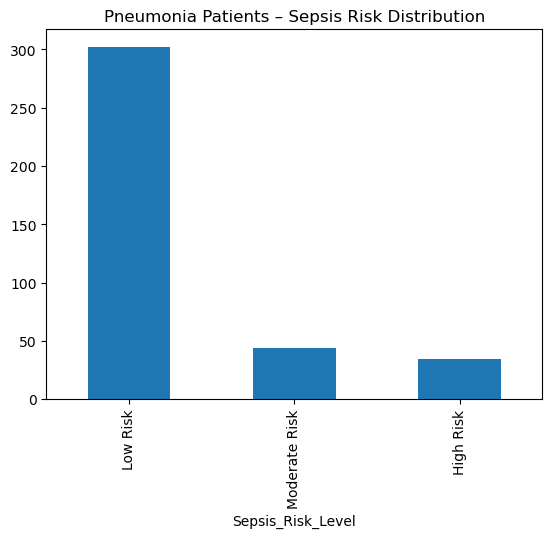

In [42]:
# RISK DISTRIBUTION GRAPH
import matplotlib.pyplot as plt

results_pneumonia["Sepsis_Risk_Level"].value_counts().plot(
    kind="bar",
    title="Pneumonia Patients – Sepsis Risk Distribution"
)
plt.show()



Evaluate the Model

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7657894736842106


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))


Precision: 0.7662113041223748
Recall: 0.7657894736842106
F1-score: 0.7619286703501796


In [45]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))


              precision    recall  f1-score   support

         Low       0.76      0.56      0.64        68
      Medium       0.79      0.75      0.77       103
        High       0.76      0.84      0.80       209

    accuracy                           0.77       380
   macro avg       0.77      0.72      0.74       380
weighted avg       0.77      0.77      0.76       380




Confusion Matrix (VISUAL UNDERSTANDING)

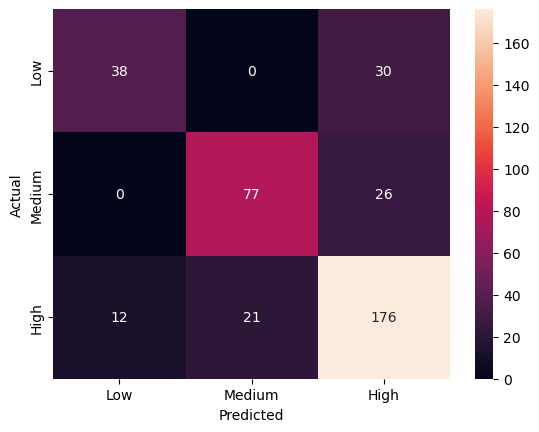

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [47]:
import joblib
joblib.dump(model, "pneumonia_logistic_model.pkl")
joblib.dump(scaler, "pneumonia_scaler.pkl")
joblib.dump(label_encoder, "pneumonia_label_encoder.pkl")


['pneumonia_label_encoder.pkl']


We used Logistic Regression as a baseline classifier due to its interpretability and suitability for multi-class risk prediction. The model achieved satisfactory recall for high-risk sepsis cases.

Train Random Forest model and compare

In [48]:
import pandas as pd
import numpy as np

# LOAD CLEAN DATASET
data = pd.read_csv("pneumonia_sepsis_ready.csv")
data.head()


,Gender,Age,Cough,Fever,Shortness_of_breath,Chest_pain,Fatigue,Confusion,oxygen_saturation,Crackles,wbc_count,body_temperature,heart_rate,respiratory_rate,systolic_bp,platelets,sepsis_risk
0,0,63,0.0,1,1,1,1,0.0,97.0,1,9803.0,36.7,98,14,139,292007,Low
1,1,65,1.0,0,1,2,1,0.0,87.0,0,9803.0,36.8,111,27,100,116999,High
2,0,45,1.0,0,1,2,2,1.0,90.0,1,9803.0,38.1,88,19,111,293594,Medium
3,1,10,1.0,0,1,1,1,0.0,96.0,1,9803.0,35.0,74,13,139,138712,Low
4,1,2,1.0,1,1,1,1,0.0,87.0,1,9803.0,37.7,102,22,113,295623,Medium


In [49]:
data.shape
data["sepsis_risk"].value_counts()

sepsis_risk
Medium    1047
Low        513
High       340
Name: count, dtype: int64

In [50]:
# DEFINE FEATURES (X) & TARGET (y)
X = data.drop("sepsis_risk", axis=1)
y = data["sepsis_risk"]


In [51]:
# ENCODE TARGET LABEL
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_encoder.classes_


array(['High', 'Low', 'Medium'], dtype=object)

In [70]:
# TRAIN–TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)


(1520, 16) (380, 16)


In [71]:
# FEATURE SCALING
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)



Create the Random Forest Model:

n_estimators=200 → 200 trees (strong model)

max_depth=10 → avoids overfitting

random_state=42 → reproducible results

In [72]:
# Create the Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced"
)

#Train the Random Forest Model
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=3, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [73]:
#Predict Using Random Forest
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)

In [74]:
# EXTRACT HIGH-RISK PROBABILITY
high_risk_index = list(label_encoder.classes_).index("High")
y_high_risk_prob = y_proba[:, high_risk_index]


In [75]:
# 🔹 Sepsis Risk Level Classification Function
def classify_sepsis_risk(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Moderate Risk"
    else:
        return "High Risk"


In [76]:
#  Apply risk level classification
risk_levels = [classify_sepsis_risk(p) for p in y_high_risk_prob]

In [77]:
#  Create results dataframe
results_pneumonia = pd.DataFrame({
    "Disease": "Pneumonia",
    "Actual_Sepsis": y_test,
    "Predicted_Sepsis": y_pred,
    "Sepsis_Probability": y_high_risk_prob,
    "Sepsis_Risk_Level": risk_levels
})

# Decode labels
results_pneumonia["Actual_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Actual_Sepsis"])
results_pneumonia["Predicted_Sepsis"] = label_encoder.inverse_transform(results_pneumonia["Predicted_Sepsis"])

results_pneumonia.head()


,Disease,Actual_Sepsis,Predicted_Sepsis,Sepsis_Probability,Sepsis_Risk_Level
0,Pneumonia,Medium,Medium,0.221703,Low Risk
1,Pneumonia,Low,Low,0.000000,Low Risk
2,Pneumonia,Medium,Medium,0.024355,Low Risk
3,Pneumonia,Low,Low,0.000302,Low Risk
4,Pneumonia,Medium,Medium,0.227159,Low Risk


In [78]:
# CHECK SEPSIS RISK DISTRIBUTION
results_pneumonia["Sepsis_Risk_Level"].value_counts()

Sepsis_Risk_Level
Low Risk         286
High Risk         48
Moderate Risk     46
Name: count, dtype: int64

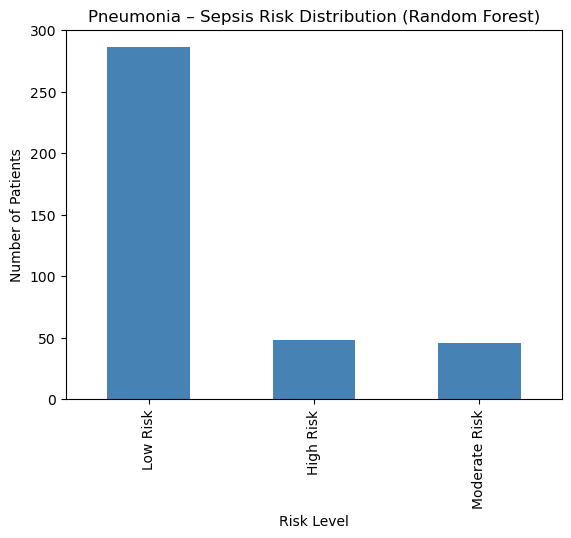

In [79]:
import matplotlib.pyplot as plt

results_pneumonia["Sepsis_Risk_Level"].value_counts().plot(
    kind="bar",
    title="Pneumonia – Sepsis Risk Distribution (Random Forest)",
    color="steelblue"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.show()



Evaluate Random Forest:

ACCURACY

In [80]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.9552631578947368


In [81]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-score:", f1_score(y_test, y_pred, average="weighted"))


Precision: 0.9551231048662122
Recall: 0.9552631578947368
F1-score: 0.9545946108712093


In [82]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low", "Medium", "High"]
))


              precision    recall  f1-score   support

         Low       0.95      0.85      0.90        68
      Medium       0.96      1.00      0.98       103
        High       0.95      0.97      0.96       209

    accuracy                           0.96       380
   macro avg       0.96      0.94      0.95       380
weighted avg       0.96      0.96      0.95       380



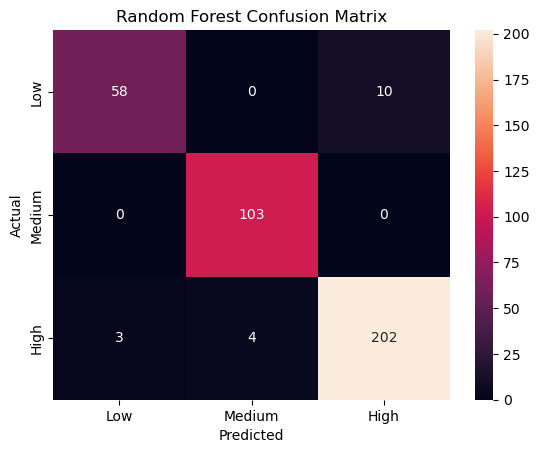

In [83]:
#Confusion Matrix (Random Forest)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [84]:
#comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

comparison


,Model,Accuracy
0,Logistic Regression,0.765789
1,Random Forest,0.955263


In [85]:
#Save Random Forest Model
import joblib

joblib.dump(rf_model, "pneumonia_random_forest_model.pkl")
joblib.dump(scaler, "pneumonia_scaler.pkl")
joblib.dump(list(X.columns), "models/pneumonia_features.pkl")
joblib.dump(label_encoder, "pneumonia_label_encoder.pkl")

['pneumonia_label_encoder.pkl']


We trained Logistic Regression as a baseline model and Random Forest as an advanced ensemble model. Random Forest achieved better performance, particularly higher recall for high-risk sepsis cases, and was selected as the final model.

In [86]:
results_pneumonia.to_csv("results_pneumonia.csv", index=False)

In [87]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.9552631578947368

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.85      0.90        68
           1       0.96      1.00      0.98       103
           2       0.95      0.97      0.96       209

    accuracy                           0.96       380
   macro avg       0.96      0.94      0.95       380
weighted avg       0.96      0.96      0.95       380


Confusion Matrix:
 [[ 58   0  10]
 [  0 103   0]
 [  3   4 202]]


In [88]:
rf_model.feature_names_in_

array(['Gender', 'Age', 'Cough', 'Fever', 'Shortness_of_breath',
       'Chest_pain', 'Fatigue', 'Confusion', 'oxygen_saturation',
       'Crackles', 'wbc_count', 'body_temperature', 'heart_rate',
       'respiratory_rate', 'systolic_bp', 'platelets'], dtype=object)

In [89]:
X_test_scaled = X_test_scaled[rf_model.feature_names_in_]


In [90]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test_scaled),
    multi_class='ovr',
    average='macro'
)

print("Multi-class ROC-AUC:", roc_auc)


Multi-class ROC-AUC: 0.9937084604324431


In [91]:
probs = rf_model.predict_proba(X_test)

print("First 5 probability rows:")
print(probs[:5])


First 5 probability rows:
[[0.4496704  0.05305837 0.49727123]
 [0.16084095 0.06857282 0.77058623]
 [0.44207334 0.04444157 0.51348509]
 [0.16408912 0.08024812 0.75566276]
 [0.44859989 0.04385358 0.50754653]]


In [92]:
print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [93]:
X_test.iloc[0]

Gender                      0.0
Age                        40.0
Cough                       0.0
Fever                       1.0
Shortness_of_breath         1.0
Chest_pain                  1.0
Fatigue                     1.0
Confusion                   1.0
oxygen_saturation          90.0
Crackles                    1.0
wbc_count                9803.0
body_temperature           40.1
heart_rate                 84.0
respiratory_rate           19.0
systolic_bp               110.0
platelets              277214.0
Name: 956, dtype: float64

In [94]:
rf_model.predict(X_test_scaled.iloc[[0]])
rf_model.predict_proba(X_test_scaled.iloc[[0]])

array([[0.22170299, 0.0029211 , 0.77537591]])

In [95]:
# Select one test sample
sample_index = 0
sample_raw = X_test.iloc[[sample_index]]
sample_scaled = X_test_scaled.iloc[[sample_index]]

print("Raw sample:")
print(sample_raw)

print("\nScaled sample:")
print(sample_scaled)

pred = rf_model.predict(sample_scaled)[0]
probs = rf_model.predict_proba(sample_scaled)[0]

print("\nPrediction (encoded):", pred)
print("Prediction (decoded):", label_encoder.inverse_transform([pred])[0])
print("Probabilities:", probs)
print("Selected probability:", probs[pred])

Raw sample:
     Gender  Age  Cough  Fever  Shortness_of_breath  Chest_pain  Fatigue  \
956       0   40    0.0      1                    1           1        1   

     Confusion  oxygen_saturation  Crackles  wbc_count  body_temperature  \
956        1.0               90.0         1     9803.0              40.1   

     heart_rate  respiratory_rate  systolic_bp  platelets  
956          84                19          110     277214  

Scaled sample:
     Gender       Age     Cough     Fever  Shortness_of_breath  Chest_pain  \
0 -0.931301 -0.237367 -1.060009 -0.167621            -0.620444   -0.609571   

    Fatigue  Confusion  oxygen_saturation  Crackles  wbc_count  \
0 -0.610417   1.634472          -0.636935  1.174188   0.011747   

   body_temperature  heart_rate  respiratory_rate  systolic_bp  platelets  
0          1.116894   -0.361072         -0.101679    -0.549577   1.322123  

Prediction (encoded): 2
Prediction (decoded): Medium
Probabilities: [0.22170299 0.0029211  0.77537591]
